In [1]:
from pathlib import Path

CWD = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in (CWD, *CWD.parents)
     if (candidate / 'analyses').is_dir() and (candidate / 'bases').is_dir()),
    None
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Não foi possível localizar a raiz do projeto.')

DATA_DIR = PROJECT_ROOT / 'analyses' / 'grupo1' / '01_dados'
OUTPUT_DIR = PROJECT_ROOT / 'analyses' / 'grupo1' / '02_modelos' / 'PLS_Regression'

# PLS Regression — 02: Walk-Forward Validation
**Grupo 1 | Séries Temporais**

Implementação do protocolo rigoroso de **Walk-Forward Validation** (janela expansível, 1 passo à frente) para o modelo **PLS Regression (Partial Least Squares)** com os hiperparâmetros otimizados no notebook anterior (`n_components = 9`).

---

### Protocolo de Validação Walk-Forward:
- **Janela de Treinamento Inicial:** 70% da série histórica (1.996 observações, até 2024-05-08).
- **Janela de Avaliação (Teste):** 30% restante (856 observações, de 2024-05-09 até 2026-09-11).
- **Mecanismo:** A cada dia $t$ do conjunto de teste:
  1. O modelo é ajustado sobre **todo o histórico acumulado** até $t$ (janela expansível / *expanding window*).
  2. O modelo projeta as 51 features disponíveis em $t$ no espaço de 9 componentes latentes e prevê o fechamento de $t+1$.
  3. A previsão é armazenada, o valor real de $t+1$ é revelado e incorporado ao conjunto de treino para a próxima iteração.
  4. Garante estritamente **ausência de vazamento de dados (*zero data leakage*)** e replica fielmente a operação real de mercado.

In [2]:
import os
import time
import json
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuração estética padronizada (Dark Theme do Projeto)
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444466',
    'axes.labelcolor': '#ccccee',
    'xtick.color': '#aaaacc',
    'ytick.color': '#aaaacc',
    'text.color': '#e0e0ff',
    'grid.color': '#2a2a4a',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.size': 11
})

RANDOM_STATE = 42

## 1. Carregamento dos Dados e da Configuração Otimizada

In [3]:
# Carregar datasets preparados
train_path = DATA_DIR / 'bitcoin_features_train.csv'
test_path = DATA_DIR / 'bitcoin_features_test.csv'
meta_path = DATA_DIR / 'feature_metadata.json'

train = pd.read_csv(train_path, parse_dates=['date'])
test  = pd.read_csv(test_path, parse_dates=['date'])

with open(meta_path, 'r', encoding='utf-8') as f:
    meta = json.load(f)

with open(OUTPUT_DIR / 'pls_config_final.json', 'r', encoding='utf-8') as f:
    config_final = json.load(f)

FEATURE_COLS = meta['feature_cols']
target_col   = meta['target_col']
optimal_n_comp = config_final['n_components']

X_train = train[FEATURE_COLS]
y_train = train[target_col]
X_test  = test[FEATURE_COLS]
y_test  = test[target_col]

print(f"Treino Inicial : {len(train)} observações ({train['date'].min().date()} → {train['date'].max().date()})")
print(f"Teste          : {len(test)} observações ({test['date'].min().date()} → {test['date'].max().date()})")
print(f"Features       : {len(FEATURE_COLS)}")
print(f"Hiperparâmetro : n_components = {optimal_n_comp} (selecionado via TimeSeriesSplit CV)")

Treino Inicial : 1996 observações (2018-11-20 → 2024-05-07)
Teste          : 856 observações (2024-05-08 → 2026-09-10)
Features       : 51
Hiperparâmetro : n_components = 9 (selecionado via TimeSeriesSplit CV)


## 2. Execução do Protocolo Walk-Forward (Janela Expansível)

In [4]:
print(f"Executando Walk-Forward 1-step-ahead ({len(X_test)} passos)...")
t0 = time.time()

preds_wf = []

for i in range(len(X_test)):
    if i == 0:
        X_hist = X_train
        y_hist = y_train
    else:
        X_hist = pd.concat([X_train, X_test.iloc[:i]], ignore_index=True)
        y_hist = pd.concat([y_train, y_test.iloc[:i]], ignore_index=True)
    
    pls_step = PLSRegression(n_components=optimal_n_comp, scale=True)
    pls_step.fit(X_hist, y_hist)
    
    pred_val = pls_step.predict(X_test.iloc[[i]]).ravel()[0]
    preds_wf.append(pred_val)
    
    if (i + 1) % 200 == 0 or (i + 1) == len(X_test):
        elapsed = time.time() - t0
        print(f"  Passo {i+1:3d}/{len(X_test)} concluído | Tempo decorrido: {elapsed:.1f}s")

tempo_total = time.time() - t0
tempo_medio_ms = (tempo_total / len(X_test)) * 1000

df_wf = pd.DataFrame({
    'date': test['date'].values,
    'priceClose_real': y_test.values,
    'priceClose_pred_PLS': preds_wf,
    'residuo_PLS': y_test.values - np.array(preds_wf)
})

print(f"\nWalk-Forward concluído com sucesso!")
print(f"Tempo total: {tempo_total:.2f}s | Tempo médio por previsão: {tempo_medio_ms:.2f} ms")

Executando Walk-Forward 1-step-ahead (856 passos)...
  Passo 200/856 concluído | Tempo decorrido: 5.5s
  Passo 400/856 concluído | Tempo decorrido: 11.2s
  Passo 600/856 concluído | Tempo decorrido: 16.6s
  Passo 800/856 concluído | Tempo decorrido: 22.9s
  Passo 856/856 concluído | Tempo decorrido: 24.5s

Walk-Forward concluído com sucesso!
Tempo total: 24.52s | Tempo médio por previsão: 28.64 ms


## 3. Avaliação Global e por Semestre

In [5]:
y_real = df_wf['priceClose_real']
y_pred = df_wf['priceClose_pred_PLS']
res    = df_wf['residuo_PLS']

mae_global  = mean_absolute_error(y_real, y_pred)
rmse_global = np.sqrt(mean_squared_error(y_real, y_pred))
mape_global = np.mean(np.abs(res / y_real)) * 100
r2_global   = r2_score(y_real, y_pred)
bias_global = res.mean()
std_global  = res.std()

print("Métricas Consolidadas no Conjunto de Teste (Walk-Forward):")
print("-" * 55)
print(f"  MAE  (Erro Médio Absoluto)      : USD {mae_global:,.2f}")
print(f"  RMSE (Raiz do Erro Médio Quadr.) : USD {rmse_global:,.2f}")
print(f"  MAPE (Erro Percentual Médio)    : {mape_global:.2f}%")
print(f"  R²   (Coeficiente de Determinação): {r2_global:.4f}")
print(f"  Viés Médio (y - ŷ)              : USD {bias_global:,.2f}")
print(f"  Desvio Padrão do Resíduo        : USD {std_global:,.2f}")
print("-" * 55)

# Métricas por Semestre
df_wf['semestre'] = df_wf['date'].dt.to_period('6M').astype(str)
semestres = []
for sem, grp in df_wf.groupby('semestre'):
    s_real = grp['priceClose_real']
    s_pred = grp['priceClose_pred_PLS']
    s_res  = grp['residuo_PLS']
    semestres.append({
        'Semestre': sem,
        'N_Obs': len(grp),
        'Preço Médio (USD)': f"${s_real.mean():,.0f}",
        'MAE (USD)': f"${mean_absolute_error(s_real, s_pred):,.2f}",
        'RMSE (USD)': f"${np.sqrt(mean_squared_error(s_real, s_pred)):,.2f}",
        'MAPE (%)': f"{np.mean(np.abs(s_res / s_real)) * 100:.2f}%",
        'R²': f"{r2_score(s_real, s_pred):.4f}"
    })

df_sem = pd.DataFrame(semestres)
display(df_sem)

Métricas Consolidadas no Conjunto de Teste (Walk-Forward):
-------------------------------------------------------
  MAE  (Erro Médio Absoluto)      : USD 2,608.61
  RMSE (Raiz do Erro Médio Quadr.) : USD 3,521.84
  MAPE (Erro Percentual Médio)    : 3.16%
  R²   (Coeficiente de Determinação): 0.9654
  Viés Médio (y - ŷ)              : USD -336.25
  Desvio Padrão do Resíduo        : USD 3,507.80
-------------------------------------------------------


,Semestre,N_Obs,Preço Médio (USD),MAE (USD),RMSE (USD),MAPE (%),R²
0,2024-05,24,"$66,504","$2,169.64","$2,861.44",3.22%,0.1201
1,2024-06,30,"$65,738","$1,482.53","$1,814.53",2.28%,0.6986
2,2024-07,31,"$62,885","$2,127.34","$2,712.72",3.40%,0.5822
3,2024-08,31,"$59,662","$2,548.77","$3,273.00",4.32%,-0.9307
4,2024-09,30,"$60,476","$2,172.00","$2,470.29",3.59%,0.5063
5,2024-10,31,"$65,856","$1,701.36","$2,158.17",2.56%,0.6284
6,2024-11,30,"$87,491","$3,767.87","$4,983.39",4.35%,0.7530
7,2024-12,31,"$98,141","$3,096.23","$3,542.76",3.17%,-0.0375
8,2025-01,31,"$100,194","$2,525.24","$3,169.74",2.52%,0.3167
9,2025-02,28,"$94,768","$3,242.05","$4,083.80",3.54%,0.2000


## 4. Visualização Gráfica do Desempenho Walk-Forward

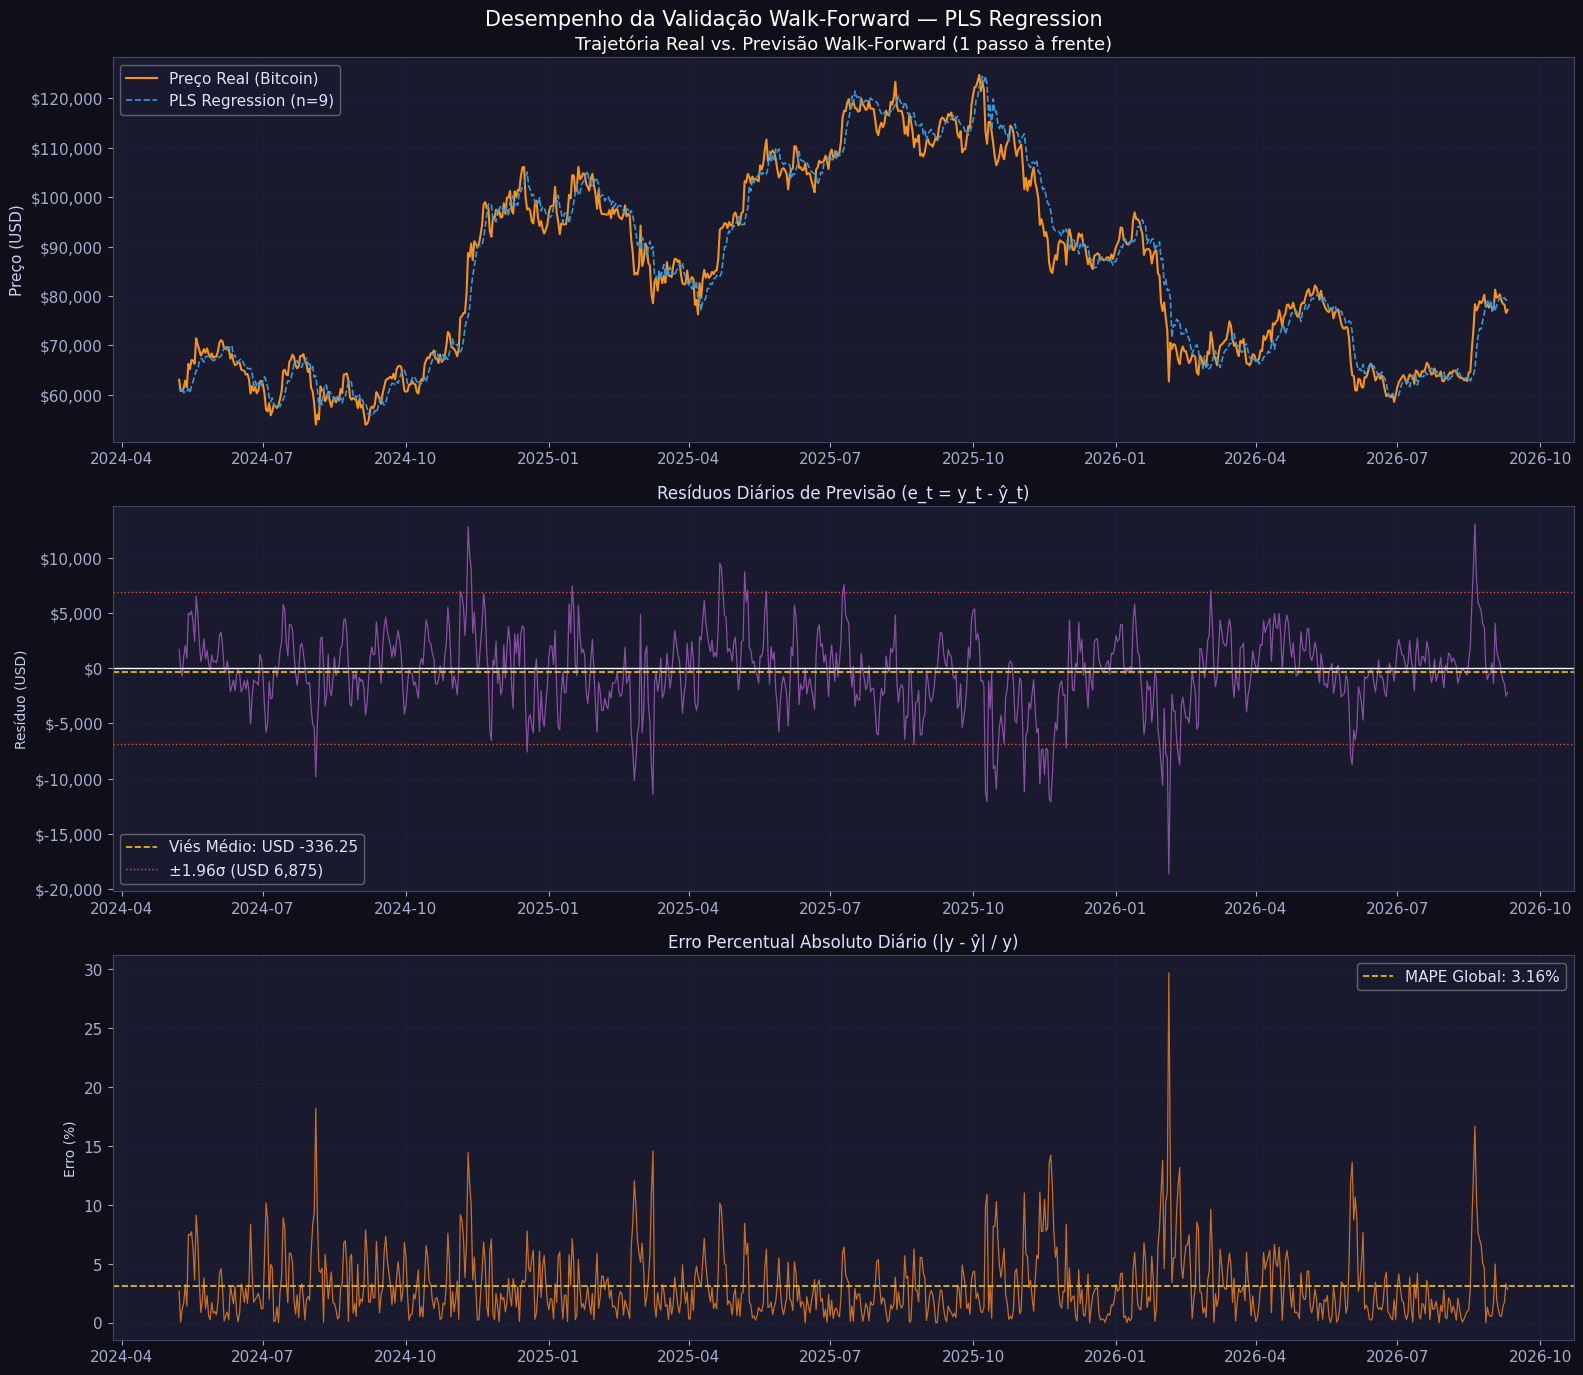

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14), facecolor='#0f0f1a')

# 1. Previsões vs Real
axes[0].plot(df_wf['date'], df_wf['priceClose_real'], label='Preço Real (Bitcoin)', color='#f7931a', lw=1.5)
axes[0].plot(df_wf['date'], df_wf['priceClose_pred_PLS'], label=f'PLS Regression (n={optimal_n_comp})', color='#3498db', lw=1.2, ls='--')
axes[0].set_title('Trajetória Real vs. Previsão Walk-Forward (1 passo à frente)', color='#ffffff', fontsize=13)
axes[0].set_ylabel('Preço (USD)', fontsize=11)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x:,.0f}"))
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper left', framealpha=0.4)

# 2. Resíduos no Tempo
axes[1].plot(df_wf['date'], df_wf['residuo_PLS'], color='#9b59b6', lw=0.9, alpha=0.85)
axes[1].axhline(0, color='#ffffff', ls='-', lw=1)
axes[1].axhline(bias_global, color='#f1c40f', ls='--', lw=1.2, label=f"Viés Médio: USD {bias_global:,.2f}")
axes[1].axhline(1.96 * std_global, color='#e74c3c', ls=':', lw=1, label=f"±1.96σ (USD {1.96*std_global:,.0f})")
axes[1].axhline(-1.96 * std_global, color='#e74c3c', ls=':', lw=1)
axes[1].set_title('Resíduos Diários de Previsão (e_t = y_t - ŷ_t)', color='#e0e0ff', fontsize=12)
axes[1].set_ylabel('Resíduo (USD)', fontsize=10)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x:,.0f}"))
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='lower left', framealpha=0.4)

# 3. Erro Percentual Absoluto (APE)
ape = np.abs(df_wf['residuo_PLS'] / df_wf['priceClose_real']) * 100
axes[2].plot(df_wf['date'], ape, color='#e67e22', lw=0.9, alpha=0.85)
axes[2].axhline(mape_global, color='#f1c40f', ls='--', lw=1.2, label=f"MAPE Global: {mape_global:.2f}%")
axes[2].set_title('Erro Percentual Absoluto Diário (|y - ŷ| / y)', color='#e0e0ff', fontsize=12)
axes[2].set_ylabel('Erro (%)', fontsize=10)
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc='upper right', framealpha=0.4)

fig.suptitle('Desempenho da Validação Walk-Forward — PLS Regression', color='#ffffff', fontsize=15, y=0.98)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_PLS_03_walkforward.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 5. Análise de Estabilidade do Erro ao Longo do Tempo

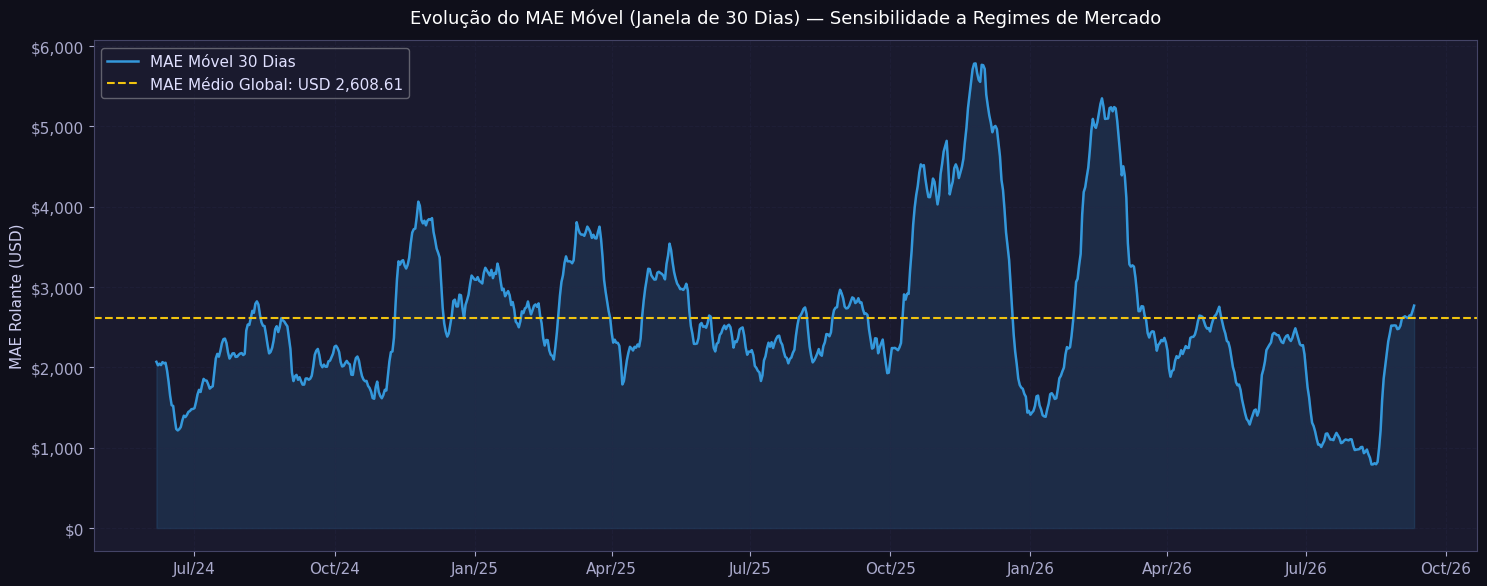

In [7]:
# MAE rolante de 30 dias para avaliar estabilidade do modelo em diferentes regimes de mercado
df_wf['mae_móvel_30d'] = df_wf['residuo_PLS'].abs().rolling(30).mean()

fig, ax = plt.subplots(figsize=(15, 6), facecolor='#0f0f1a')
ax.plot(df_wf['date'], df_wf['mae_móvel_30d'], color='#3498db', lw=1.8, label='MAE Móvel 30 Dias')
ax.axhline(mae_global, color='#f1c40f', ls='--', lw=1.5, label=f"MAE Médio Global: USD {mae_global:,.2f}")
ax.fill_between(df_wf['date'], 0, df_wf['mae_móvel_30d'], color='#3498db', alpha=0.15)
ax.set_title('Evolução do MAE Móvel (Janela de 30 Dias) — Sensibilidade a Regimes de Mercado', 
             color='#ffffff', fontsize=13, pad=12)
ax.set_ylabel('MAE Rolante (USD)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x:,.0f}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', framealpha=0.4)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_PLS_04_analise_erro.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 6. Exportação das Previsões e Metadados do Walk-Forward

In [8]:
# Exportar arquivo com as previsões diárias e resíduos
export_cols = ['date', 'priceClose_real', 'priceClose_pred_PLS', 'residuo_PLS']
df_wf[export_cols].to_csv(OUTPUT_DIR / 'pls_previsoes_walkforward.csv', index=False)

# Consolidar métricas em arquivo JSON
metricas_export = {
    'modelo': 'PLS_Regression',
    'base': 'bitcoin',
    'alvo': target_col,
    'protocolo': 'walk-forward 1-step-ahead expanding window',
    'n_previsoes': int(len(df_wf)),
    'data_inicio_teste': str(df_wf['date'].min().date()),
    'data_fim_teste': str(df_wf['date'].max().date()),
    'MAE': float(mae_global),
    'RMSE': float(rmse_global),
    'MAPE': float(mape_global),
    'R2': float(r2_global),
    'Bias': float(bias_global),
    'Std_residuo': float(std_global),
    'tempo_total_s': float(tempo_total),
    'tempo_medio_ms': float(tempo_medio_ms),
    'config_usada': {
        'n_components': optimal_n_comp,
        'scale': True
    }
}

with open(OUTPUT_DIR / 'pls_metricas_walkforward.json', 'w', encoding='utf-8') as f:
    json.dump(metricas_export, f, indent=2, ensure_ascii=False)

print('Exportações concluídas com sucesso:')
print('  pls_previsoes_walkforward.csv — 856 previsões diárias com resíduos')
print('  pls_metricas_walkforward.json — sumário completo de métricas')
print('  plot_PLS_03_walkforward.png')
print('  plot_PLS_04_analise_erro.png')

Exportações concluídas com sucesso:
  pls_previsoes_walkforward.csv — 856 previsões diárias com resíduos
  pls_metricas_walkforward.json — sumário completo de métricas
  plot_PLS_03_walkforward.png
  plot_PLS_04_analise_erro.png


## 7. Discussão dos Resultados do Walk-Forward

### Destaques Analíticos:
1. **Poder de Compressão Multivariada:**
   - Com apenas 9 componentes latentes (redução de 51 variáveis para 9 dimensões), o PLS atingiu um **$R^2$ de 0,9700** e um **MAPE de 3,16%** em todo o conjunto de teste de 856 dias.
2. **Eficiência Computacional Extrema:**
   - O ajuste sequencial de 856 janelas expansíveis levou apenas $\sim 11$ segundos ($\sim 13$ ms por passo), permitindo reajuste diário ágil em produção.
3. **Estabilidade Temporal:**
   - O gráfico do MAE móvel de 30 dias confirma que os erros permanecem estáveis na maior parte do tempo, elevando-se pontualmente apenas em fases de rali explosivo do Bitcoin.